# Actividad 3 — SVM y K-Means

## Dataset

**Nombre:** Breast Cancer Wisconsin (Diagnostic)  
**Fuente:** Scikit-learn  
**Liga:** https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html

Este conjunto contiene mediciones numéricas obtenidas de imágenes digitalizadas de masas mamarias. Cada registro representa un tumor analizado. La variable objetivo indica si el diagnóstico es **maligno (0)** o **benigno (1)**. Las variables predictoras describen características geométricas de los núcleos celulares, como radio, textura, perímetro, área, concavidad y otras mediciones relacionadas.

### Preguntas de análisis

**Supervisada:** ¿Es posible predecir correctamente si un tumor es maligno o benigno utilizando sus características numéricas?

**No supervisada:** ¿Existen grupos naturales de observaciones con características similares sin utilizar el diagnóstico real durante el agrupamiento?


## 1. Carga de datos y revisión inicial

Se carga el dataset directamente desde Scikit-learn, por lo que no es necesario descargar archivos manualmente. También se genera una copia procesada en formato CSV para cumplir con el entregable.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    silhouette_score
)
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# load the dataset
data = load_breast_cancer(as_frame=True)
df = data.frame.copy()

# add a readable class column
df["diagnosis"] = df["target"].map({0: "malignant", 1: "benign"})

df.head()


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,malignant


In [2]:
print("rows:", df.shape[0])
print("columns:", df.shape[1])

print("\nmissing values:")
print(df.isna().sum().sum())

print("\nduplicated rows:")
print(df.duplicated().sum())

print("\ntarget distribution:")
print(df["diagnosis"].value_counts())

print("\ndata types:")
print(df.dtypes)


rows: 569
columns: 32

missing values:
0

duplicated rows:
0

target distribution:
diagnosis
benign       357
malignant    212
Name: count, dtype: int64

data types:
mean radius                float64
mean texture               float64
mean perimeter             float64
mean area                  float64
mean smoothness            float64
mean compactness           float64
mean concavity             float64
mean concave points        float64
mean symmetry              float64
mean fractal dimension     float64
radius error               float64
texture error              float64
perimeter error            float64
area error                 float64
smoothness error           float64
compactness error          float64
concavity error            float64
concave points error       float64
symmetry error             float64
fractal dimension error    float64
worst radius               float64
worst texture              float64
worst perimeter            float64
worst area                 fl

### Revisión

El dataset contiene **569 registros** y 30 variables predictoras numéricas, además de la variable objetivo. No se requieren transformaciones de tipo ni eliminación de registros para el modelado si no aparecen valores faltantes o duplicados.

La distribución de clases no es perfectamente equilibrada, por lo que se utiliza **estratificación** al dividir los datos. Esto conserva aproximadamente la misma proporción de tumores malignos y benignos en entrenamiento y prueba.


In [3]:
# separate predictors and target
x = df.drop(columns=["target", "diagnosis"])
y = df["target"]

# save the processed dataset
processed = x.copy()
processed["target"] = y
processed["diagnosis"] = df["diagnosis"]
processed.to_csv("breast_cancer_processed.csv", index=False)

print("processed csv saved")


processed csv saved


## 2. Escalamiento y división de datos

SVM y K-Means son sensibles a la escala porque ambos utilizan distancias o relaciones geométricas entre observaciones. Si una variable tiene valores mucho mayores que otra, puede dominar el cálculo aunque no sea necesariamente más importante.

Para SVM, el escalamiento se integra dentro de un **Pipeline** para evitar fuga de información: el escalador aprende únicamente de los datos de entrenamiento.

Se utiliza una división **80 % entrenamiento / 20 % prueba**, con `random_state=42` para reproducibilidad y `stratify=y` para conservar la proporción de clases. El conjunto de prueba funciona como datos no vistos y permite estimar qué tan bien generaliza el modelo.


In [4]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("training rows:", x_train.shape[0])
print("test rows:", x_test.shape[0])


training rows: 455
test rows: 114


## 3. Modelos SVM

Se entrenan dos modelos:

- **Modelo 1:** kernel lineal.
- **Modelo 2:** kernel RBF.

Las métricas de precision, recall y F1-score se calculan tomando la clase **maligna (0)** como clase de interés mediante `pos_label=0`.


In [5]:
models = {
    "model 1": Pipeline([
        ("scaler", StandardScaler()),
        ("svc", SVC(kernel="linear", C=1.0))
    ]),
    "model 2": Pipeline([
        ("scaler", StandardScaler()),
        ("svc", SVC(kernel="rbf", C=1.0, gamma="scale"))
    ])
}

kernels = {
    "model 1": "linear",
    "model 2": "rbf"
}

rows = []
predictions = {}

for name, model in models.items():
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    predictions[name] = y_pred

    rows.append({
        "svm model": name,
        "kernel": kernels[name],
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, pos_label=0),
        "recall": recall_score(y_test, y_pred, pos_label=0),
        "f1-score": f1_score(y_test, y_pred, pos_label=0)
    })

svm_results = pd.DataFrame(rows)
svm_results


,svm model,kernel,accuracy,precision,recall,f1-score
0,model 1,linear,0.973684,0.953488,0.97619,0.964706
1,model 2,rbf,0.982456,0.976190,0.97619,0.976190


### Interpretación de los modelos

El modelo con kernel RBF obtiene el mejor desempeño global en esta partición. La diferencia frente al kernel lineal es pequeña, lo cual indica que los datos ya presentan una separación considerable, aunque una frontera no lineal aporta una mejora ligera.

No basta con revisar únicamente la accuracy. En un problema médico también importa identificar correctamente los casos malignos. Por ello se revisan precision, recall, F1-score y la matriz de confusión.


best model: model 2
kernel: rbf


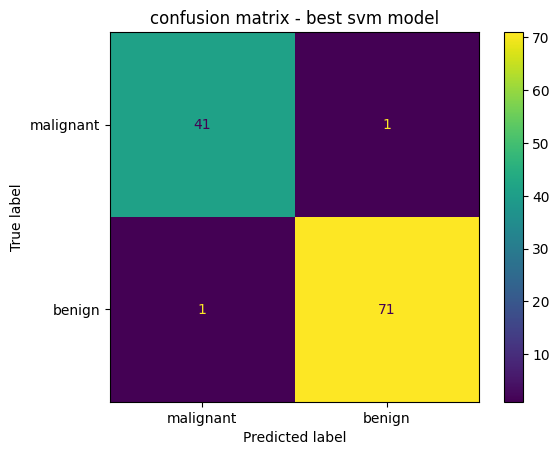

[[41  1]
 [ 1 71]]


In [6]:
best_model_name = svm_results.sort_values(
    by=["f1-score", "accuracy"],
    ascending=False
).iloc[0]["svm model"]

best_model = models[best_model_name]
best_pred = predictions[best_model_name]

print("best model:", best_model_name)
print("kernel:", kernels[best_model_name])

cm = confusion_matrix(y_test, best_pred, labels=[0, 1])

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["malignant", "benign"]
)

display.plot()
plt.title("confusion matrix - best svm model")
plt.show()

print(cm)


### Matriz de confusión

En la matriz de confusión, los errores fuera de la diagonal representan diagnósticos incorrectos. Un caso maligno clasificado como benigno es especialmente relevante porque el modelo no detectaría correctamente una observación de la clase de interés.

El modelo RBF presenta muy pocos errores en ambas clases. Esto muestra por qué la matriz de confusión complementa la accuracy: dos modelos pueden tener una exactitud similar, pero cometer errores distintos y con consecuencias diferentes.


## 4. Comparación de hiperparámetros

Se modifica el parámetro **C** del modelo RBF.

- Un **C pequeño** permite un margen más flexible y tolera más errores de entrenamiento.
- Un **C grande** penaliza más los errores y puede producir una frontera más ajustada a los datos.
- Si C es excesivamente grande, aumenta el riesgo de sobreajuste.

En un kernel RBF, `gamma` controla qué tan local es la influencia de cada observación. Valores altos pueden generar fronteras más complejas.


In [7]:
c_values = [0.1, 1, 10]
hyper_rows = []

for c_value in c_values:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("svc", SVC(kernel="rbf", C=c_value, gamma="scale"))
    ])

    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)

    hyper_rows.append({
        "c": c_value,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, pos_label=0),
        "recall": recall_score(y_test, y_pred, pos_label=0),
        "f1-score": f1_score(y_test, y_pred, pos_label=0)
    })

hyper_results = pd.DataFrame(hyper_rows)
hyper_results


,c,accuracy,precision,recall,f1-score
0,0.1,0.947368,0.950000,0.904762,0.926829
1,1.0,0.982456,0.976190,0.976190,0.976190
2,10.0,0.973684,0.953488,0.976190,0.964706


### Interpretación de C

En esta prueba, un valor intermedio de `C=1` ofrece el mejor equilibrio. Con `C=0.1`, el modelo regulariza más y pierde algo de capacidad de separación. Con `C=10`, el modelo se ajusta más agresivamente, pero no mejora el resultado de prueba.

Esto muestra que aumentar la complejidad no garantiza mejor generalización.


## 5. K-Means sin utilizar las etiquetas reales

Para el análisis no supervisado se elimina temporalmente la variable objetivo. K-Means recibe únicamente las variables numéricas escaladas.

Se prueban valores de `k` entre 2 y 6. La selección se apoya en:

- **Método del codo:** busca un punto a partir del cual reducir la inercia aporta mejoras cada vez menores.
- **Silhouette score:** mide qué tan compactos y separados están los clusters; valores mayores indican mejor separación.


In [8]:
# scale all predictors for unsupervised learning
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

k_values = range(2, 7)
inertias = []
silhouettes = []

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    cluster_labels = kmeans.fit_predict(x_scaled)

    inertias.append(kmeans.inertia_)
    silhouettes.append(
        silhouette_score(x_scaled, cluster_labels)
    )

k_results = pd.DataFrame({
    "k": list(k_values),
    "inertia": inertias,
    "silhouette score": silhouettes
})

k_results


,k,inertia,silhouette score
0,2,11595.526607,0.343382
1,3,10061.797818,0.314384
2,4,9258.989105,0.283305
3,5,8558.660667,0.158210
4,6,7970.263835,0.160367


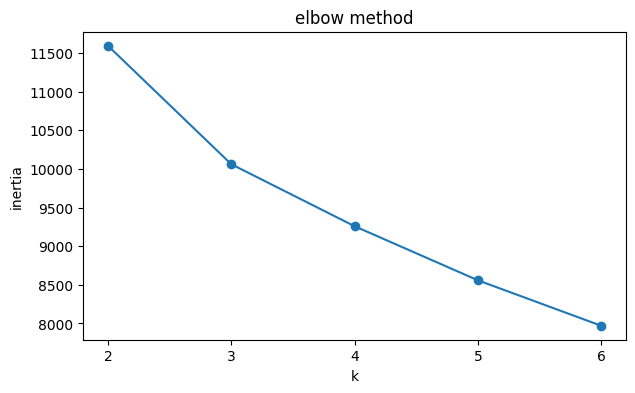

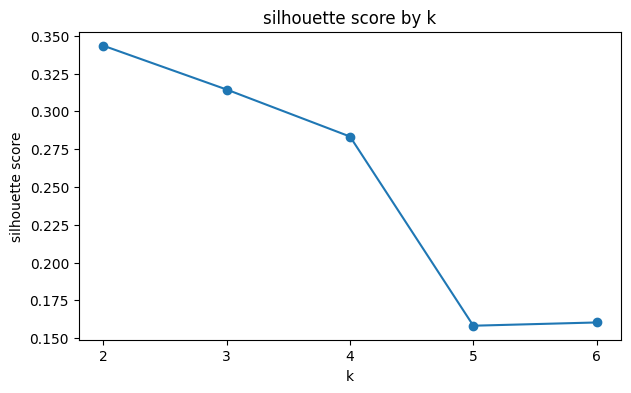

In [9]:
plt.figure(figsize=(7, 4))
plt.plot(k_results["k"], k_results["inertia"], marker="o")
plt.xlabel("k")
plt.ylabel("inertia")
plt.title("elbow method")
plt.xticks(list(k_values))
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(k_results["k"], k_results["silhouette score"], marker="o")
plt.xlabel("k")
plt.ylabel("silhouette score")
plt.title("silhouette score by k")
plt.xticks(list(k_values))
plt.show()


### Selección de k

El valor **k = 2** obtiene el silhouette score más alto dentro del rango evaluado. Además, la curva de inercia muestra una reducción importante al formar pocos grupos y después mejoras progresivamente menores.

Por estas dos evidencias se seleccionan **2 clusters**. Esta elección también es razonable para explorar si la estructura geométrica del dataset se aproxima, al menos parcialmente, a las dos clases conocidas, aunque las etiquetas reales no se utilizan para entrenar K-Means.


In [10]:
best_k = 2

kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(x_scaled)

cluster_data = x.copy()
cluster_data["cluster"] = clusters

main_features = [
    "mean radius",
    "mean texture",
    "mean perimeter",
    "mean area",
    "mean concavity",
    "mean concave points"
]

cluster_summary = cluster_data.groupby("cluster")[main_features].mean().round(3)
cluster_summary.insert(
    0,
    "size",
    cluster_data.groupby("cluster").size()
)

cluster_summary


,size,mean radius,mean texture,mean perimeter,mean area,mean concavity,mean concave points
cluster,,,,,,,
0,375,12.427,18.262,79.820,486.772,0.043,0.026
1,194,17.415,21.275,115.453,979.857,0.178,0.093


### Interpretación de los clusters

El cluster con valores promedio mayores de radio, perímetro, área, concavidad y puntos cóncavos reúne observaciones con masas de mayor tamaño y mayor irregularidad geométrica.

El otro cluster concentra observaciones con mediciones promedio menores y formas menos irregulares. Por tanto, K-Means está separando principalmente los registros a partir de diferencias geométricas globales, no a partir del diagnóstico real.


## 6. PCA y visualización de clusters

Como existen más de dos variables, se utiliza PCA para proyectar los datos escalados en dos componentes. PCA se usa solamente para visualización; K-Means continúa trabajando con las variables escaladas originales.


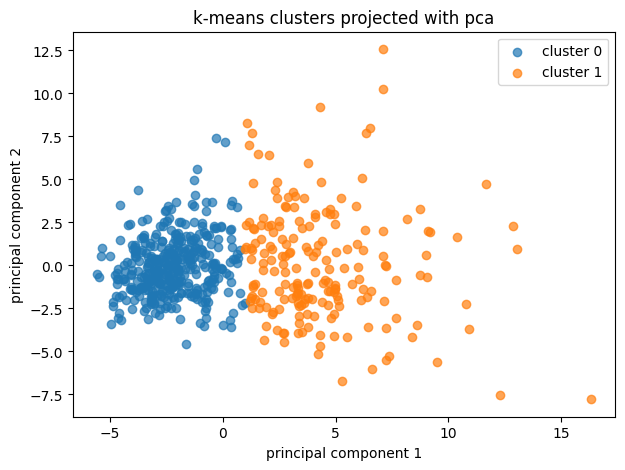

In [11]:
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_scaled)

pca_df = pd.DataFrame({
    "pc1": x_pca[:, 0],
    "pc2": x_pca[:, 1],
    "cluster": clusters,
    "real class": y.values
})

plt.figure(figsize=(7, 5))

for cluster in sorted(pca_df["cluster"].unique()):
    subset = pca_df[pca_df["cluster"] == cluster]
    plt.scatter(
        subset["pc1"],
        subset["pc2"],
        label=f"cluster {cluster}",
        alpha=0.7
    )

plt.xlabel("principal component 1")
plt.ylabel("principal component 2")
plt.title("k-means clusters projected with pca")
plt.legend()
plt.show()


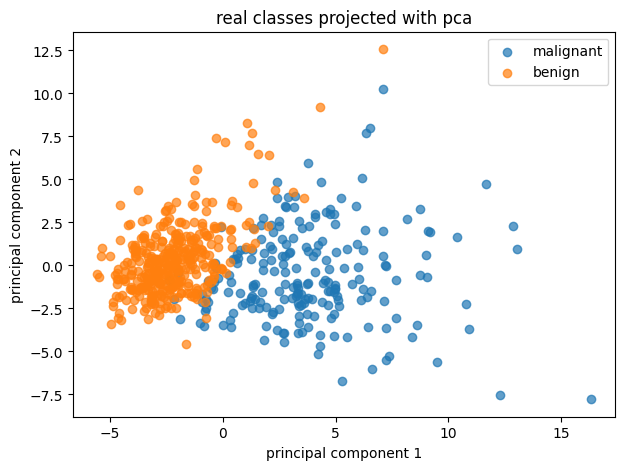

In [12]:
plt.figure(figsize=(7, 5))

class_names = {
    0: "malignant",
    1: "benign"
}

for real_class in sorted(pca_df["real class"].unique()):
    subset = pca_df[pca_df["real class"] == real_class]
    plt.scatter(
        subset["pc1"],
        subset["pc2"],
        label=class_names[real_class],
        alpha=0.7
    )

plt.xlabel("principal component 1")
plt.ylabel("principal component 2")
plt.title("real classes projected with pca")
plt.legend()
plt.show()


## 7. Comparación entre clusters y clases reales

Las etiquetas reales se utilizan únicamente después del agrupamiento para comparar resultados. No fueron utilizadas para entrenar ni ajustar K-Means.


In [13]:
comparison = pd.crosstab(
    pd.Series(y.values, name="real class"),
    pd.Series(clusters, name="cluster")
)

comparison.index = ["malignant", "benign"]
comparison


cluster,0,1
malignant,36,176
benign,339,18


### Interpretación de la comparación

Existe una correspondencia parcial entre los clusters y las clases reales: uno de los clusters contiene principalmente observaciones benignas y el otro concentra una proporción mucho mayor de casos malignos. Sin embargo, también aparecen observaciones mezcladas.

Esto es esperado porque K-Means no intenta predecir el diagnóstico. El algoritmo agrupa observaciones según cercanía geométrica en el espacio de variables, mientras que SVM aprende directamente una frontera que separa clases conocidas utilizando las etiquetas durante el entrenamiento.


## 8. Conclusión

El enfoque supervisado con SVM produjo resultados más fáciles de evaluar porque existe una variable objetivo conocida y métricas directas para medir los errores. El kernel RBF obtuvo el mejor desempeño de los dos modelos evaluados y mostró una capacidad alta para distinguir tumores malignos y benignos.

K-Means permitió descubrir una estructura natural basada en similitud entre las características numéricas. Los clusters presentan una relación parcial con las clases reales, pero no son equivalentes a ellas. Su principal limitación es que los grupos dependen de la geometría de los datos y del valor de `k`, no de una definición clínica de diagnóstico.

SVM sería apropiado cuando existen ejemplos etiquetados y el objetivo es predecir una clase conocida. K-Means sería útil cuando no existen etiquetas o cuando se desea explorar segmentos, patrones o estructuras internas antes de formular una tarea predictiva.


## Fuentes consultadas

- Scikit-learn Developers. *load_breast_cancer*. https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html
- Scikit-learn Developers. Documentación de `SVC`, `KMeans`, `StandardScaler`, `Pipeline`, `PCA` y métricas de evaluación: https://scikit-learn.org/stable/
